# TRANSFER FUNCTIONS FOR SBML MODELS

# Preliminaries

This notebook explores the construction of transfer functions for an SBML model. This is done numerically, and so only the DC gain and poles are reported.

In [77]:
import numpy as np
import pandas as pd
import tellurium as te
import sympy as sp
from scipy import signal
import matplotlib.pyplot as plt

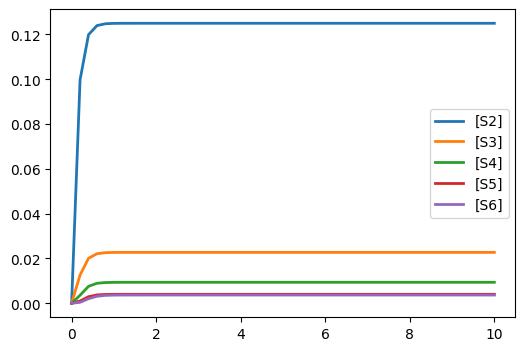

In [62]:
MODEL = """
$S1 -> S2; k1*S1
S2 -> S3; k2*S2
S3 -> ; k4*S3
S1 -> ; k5*S1
S2 -> ; k6*S2
S3 -> S4; k7*S3
S4 -> ; k8*S4
S4 -> S5; k9*S4
S5 -> ; k10*S5
S5 -> S6; k11*S5
S6 -> ; k12*S6

S1 = 1
S2 = 0
S3 = 0
"""
constants = [f"k{str(v)} = {v}" for v in range(1, 13)]
MODEL = MODEL + "\n".join(constants)
rr = te.loada(MODEL)
rr.simulate(0, 10)
rr.plot()

# Calculating Step Response from Simulation

Procedure
1. Set input boundary species to 1
2. Do steady state simulation
3. Report the steady state value of the output

In [58]:
rr.reset()
rr['S1'] = 1
rr.steadyState()
rr['S6']

0.8533333333333334

# Analytical calculation

In [65]:
A = rr.getFullJacobian()
A

      S2,  S3,  S4,  S5,  S6
S2 [[ -8,   0,   0,   0,   0],
S3  [  2, -11,   0,   0,   0],
S4  [  0,   7, -17,   0,   0],
S5  [  0,   0,   9, -21,   0],
S6  [  0,   0,   0,  11, -12]]

In [ ]:
def makeSymbolicAMatrix(num_species):
    """
    """


In [66]:
s, u, k = sp.symbols(["s", "u", "k"])
A = sp.Matrix(A)  # or convert from numpy: sp.Matrix(A_numpy)
B = sp.Matrix([[1], [0], [0], [0], [0]])
x = sp.MatrixSymbol('x', np.shape(A)[0], 1)

In [67]:
A[1,0] = k
A

Matrix([
[-8.00000000000001,              0.0,               0.0,               0.0,   0.0],
[                k,            -11.0,               0.0,               0.0,   0.0],
[              0.0, 6.99999999999997, -17.0000000000001,               0.0,   0.0],
[              0.0,              0.0,  9.00000000000002, -20.9999999999999,   0.0],
[              0.0,              0.0,               0.0,              11.0, -12.0]])

In [68]:
A*x + B*u

Matrix([
[u],
[0],
[0],
[0],
[0]]) + Matrix([
[-8.00000000000001,              0.0,               0.0,               0.0,   0.0],
[                k,            -11.0,               0.0,               0.0,   0.0],
[              0.0, 6.99999999999997, -17.0000000000001,               0.0,   0.0],
[              0.0,              0.0,  9.00000000000002, -20.9999999999999,   0.0],
[              0.0,              0.0,               0.0,              11.0, -12.0]])*x

In [69]:
(s*sp.eye(np.shape(A)[0]) - A).inv()

Matrix([
[            (1.0*s**4 + 61.0*s**3 + 1363.0*s**2 + 13227.0*s + 47124.0)/(1.0*s**5 + 69.0*s**4 + 1851.0*s**3 + 24131.0*s**2 + 152940.0*s + 376992.0),                                                                                                                                                                   0,                                                                                                                                                                              0,                                                                                                                                                                              0,                                                                                                                                      0],
[(1.0*k*s**3 + 50.0*k*s**2 + 813.000000000002*k*s + 4284.00000000001*k)/(1.0*s**5 + 69.0*s**4 + 1851.0*s**3 + 24131.0*s**2 + 152940.0*s + 376992.0),                     (1.0*s**4 + 58.0*s*

In [59]:
8/9.375

0.8533333333333334

# Transfer functions

TransferFunctionContinuous(
array([1., 1.]),
array([1., 2., 3.]),
dt: None
)


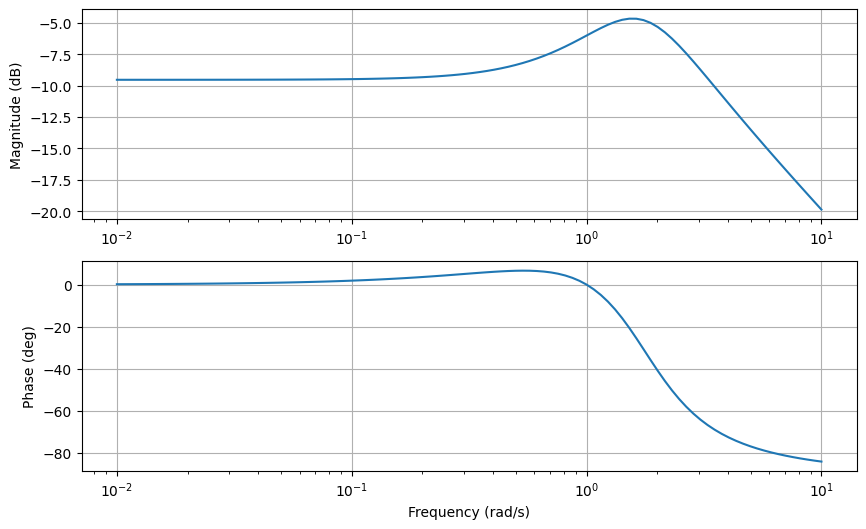

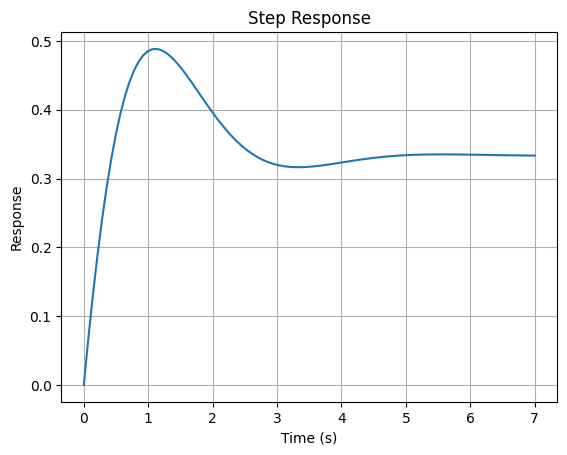

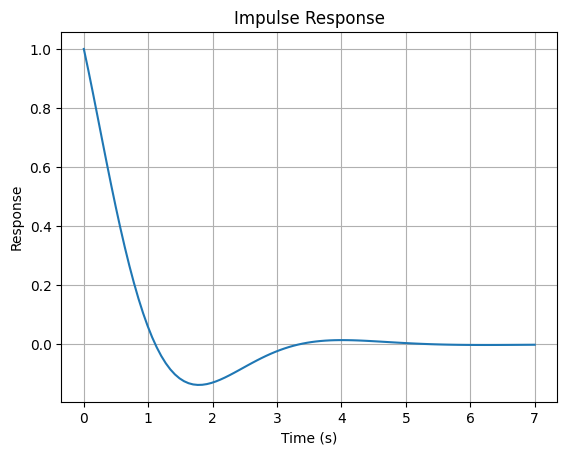

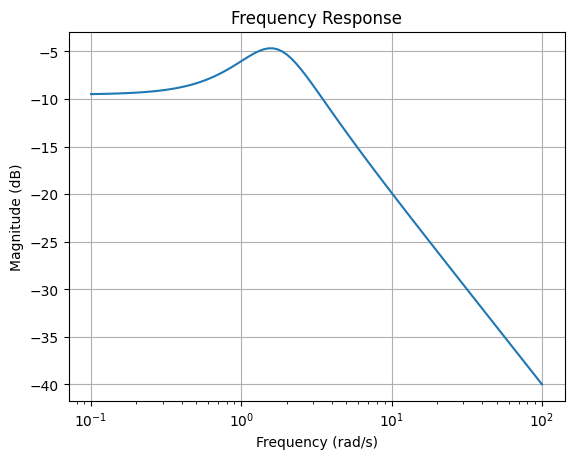

In [70]:


# Define a transfer function: H(s) = (s + 1) / (s^2 + 2s + 3)
# Numerator coefficients: s + 1 → [1, 1]
# Denominator coefficients: s^2 + 2s + 3 → [1, 2, 3]
num = [1, 1]
den = [1, 2, 3]

sys = signal.TransferFunction(num, den)

print(sys)
# Output shows the transfer function representation

# Bode plot
w, mag, phase = signal.bode(sys)
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.semilogx(w, mag)
plt.ylabel('Magnitude (dB)')
plt.grid()

plt.subplot(2, 1, 2)
plt.semilogx(w, phase)
plt.ylabel('Phase (deg)')
plt.xlabel('Frequency (rad/s)')
plt.grid()
plt.show()

# Step response
t, y = signal.step(sys)
plt.figure()
plt.plot(t, y)
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.title('Step Response')
plt.grid()
plt.show()

# Impulse response
t, y = signal.impulse(sys)
plt.figure()
plt.plot(t, y)
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.title('Impulse Response')
plt.grid()
plt.show()

# Frequency response at specific frequencies
w = np.logspace(-1, 2, 100)  # from 0.1 to 100 rad/s
w_resp, H = signal.freqs(num, den, w)
plt.figure()
plt.semilogx(w_resp, 20*np.log10(np.abs(H)))
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.title('Frequency Response')
plt.grid()
plt.show()

# Evaluating derived transfer functions

In [79]:
def dcgain(tf: signal._ltisys.TransferFunctionContinuous) -> float:
    return tf.num[-1]/tf.den[-1]

In [80]:
tf = signal.TransferFunction([692*2], [1, 69, 1851, 21431, 152940, 376992])
dcgain(tf)

0.0036711654358713183

In [81]:
tf12 = signal.TransferFunction([1, 61, 1363, 13227, 47124], [1, 69, 1851, 24131, 152940, 376992])
dcgain(tf12)

0.125

In [95]:
tv, yv = signal.step(tf12, T=np.arange(0, 10, 0.1))

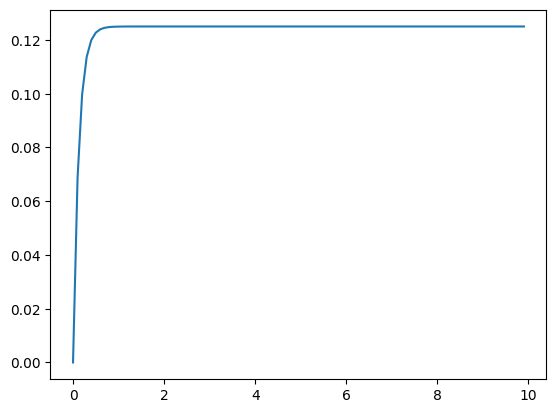

In [96]:
plt.plot(tv, yv)